In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from silhouette import silhouette_score

In [2]:
# 1. Generate Unknown Data
# Let's pretend we don't know there are exactly 5 centers
X, _ = make_blobs(n_samples=500, centers=5, cluster_std=0.8, random_state=42)

In [3]:
# 2. Test different values of K
K_range = range(2, 9)
scores = []

print("Running automatic K-discovery via Silhouette Analysis...")
for k in K_range:
    # Cluster the data
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    
    # Evaluate with OUR custom metric
    score = silhouette_score(X, labels)
    scores.append(score)
    print(f"K={k} -> Silhouette Score: {score:.3f}")

Running automatic K-discovery via Silhouette Analysis...
K=2 -> Silhouette Score: 0.604
K=3 -> Silhouette Score: 0.729
K=4 -> Silhouette Score: 0.771
K=5 -> Silhouette Score: 0.734
K=6 -> Silhouette Score: 0.669
K=7 -> Silhouette Score: 0.574
K=8 -> Silhouette Score: 0.536


In [4]:
# 3. Find the best K
best_k = K_range[np.argmax(scores)]

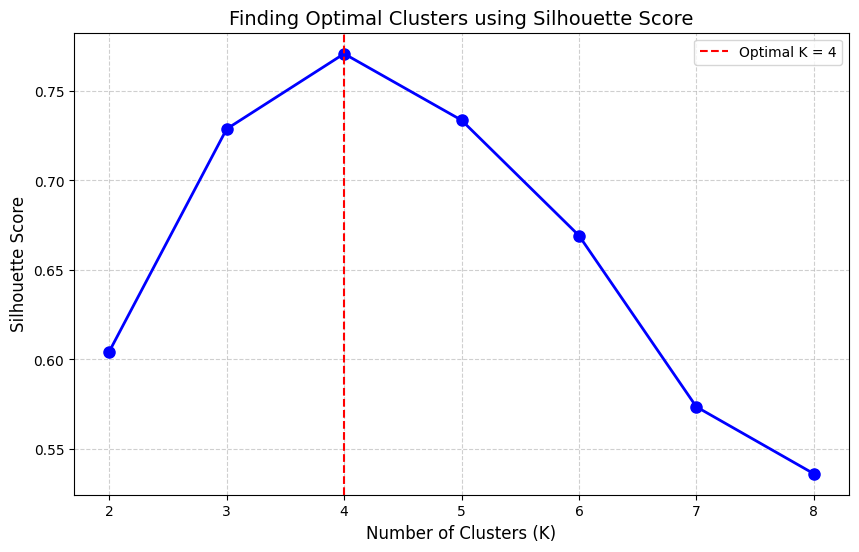


✅ The algorithm automatically discovered that 4 is the optimal number of clusters!


In [6]:
# 4. Plot the "Peak"
plt.figure(figsize=(10, 6))
plt.plot(K_range, scores, marker='o', linestyle='-', color='b', linewidth=2, markersize=8)
plt.axvline(x=best_k, color='r', linestyle='--', label=f'Optimal K = {best_k}')

plt.title("Finding Optimal Clusters using Silhouette Score", fontsize=14)
plt.xlabel("Number of Clusters (K)", fontsize=12)
plt.ylabel("Silhouette Score", fontsize=12)
plt.xticks(K_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

print(f"\n✅ The algorithm automatically discovered that {best_k} is the optimal number of clusters!")